# Telco Customer Churn — Data Preprocessing Notebook

**Dataset:** WA_Fn-UseC_-Telco-Customer-Churn.csv  
**Rows:** 7,043 | **Columns:** 21  
**Target Variable:** `Churn` (Yes / No)

---

## Problems Identified in Raw Data

Before any preprocessing, the following issues were found in the raw dataset:

### 1. `TotalCharges` stored as string with blank-space values
- The column is of type `object` (string) instead of `float`.
- 11 rows have `TotalCharges = ' '` (a blank space, not NaN). All 11 have `tenure = 0`, meaning they are brand-new customers who haven't been billed yet.
- `pd.to_numeric(..., errors='coerce')` silently converts these to `NaN`, which can cause issues downstream if not handled explicitly.

### 2. `SeniorCitizen` uses integer encoding while all other binary columns use strings
- Every other Yes/No column (`Partner`, `Dependents`, `PhoneService`, etc.) uses the strings `'Yes'`/`'No'`.
- `SeniorCitizen` uses `0` and `1` (integer), making it inconsistent with the rest and requiring special handling in any categorical encoding pipeline.

### 3. Class imbalance in the target variable `Churn`
- 73.5% of customers are `No` (did not churn), only 26.5% are `Yes`.
- Not a bug in the data, but a structural property that must be flagged — any model trained on this data needs to account for it (class weights, oversampling, etc.).

### 4. Redundant information encoded in dependent columns
- `MultipleLines` contains `'No phone service'` when `PhoneService = No`. The `PhoneService` column already captures this — the third value in `MultipleLines` is redundant.
- Six internet add-on columns (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) all contain `'No internet service'` when `InternetService = No`. Same redundancy.
- These third-state values add noise and mislead encoding if not handled (e.g. one-hot encoding treats them as a third category instead of an inherited No).

### 5. `customerID` is a non-informative identifier
- Purely a row key. It contributes zero predictive signal and must be dropped before any analysis or modeling.

### 6. `tenure = 0` edge case
- 11 customers have zero months of tenure. These are valid new signups but are the same 11 with missing `TotalCharges`. They represent a special state (customer exists but has no billing history) that deserves explicit handling rather than imputation.

### 7. No true duplicates or ID collisions
- Verified: 0 fully duplicate rows, 0 duplicate `customerID` values. No action needed.

### 8. No statistical outliers in `MonthlyCharges`
- IQR-based outlier check returned 0 outliers. The range \$18.25–\$118.75 is realistic for a telecom pricing structure.

### 9. `TotalCharges` is not a clean derivation of `tenure × MonthlyCharges`
- The average gap is ~\$45, up to \$373 difference. This is expected — `MonthlyCharges` is a snapshot of the current rate, while `TotalCharges` accumulates historical rates. Neither is wrong, but they should not be treated as perfectly collinear.

---

## Assumptions & Decisions Made During Preprocessing

| # | Decision | Reasoning |
|---|----------|-----------|
| 1 | `TotalCharges` blank rows → set to `0.0` | `tenure = 0` means no billing occurred yet. Setting to `0.0` is semantically accurate and avoids imputing a made-up value. Dropping these 11 rows was rejected — they are valid customers. |
| 2 | `SeniorCitizen` converted to `'Yes'`/`'No'` strings | Harmonizes encoding with all other binary columns. Simplifies downstream one-hot or ordinal encoding. |
| 3 | `'No phone service'` in `MultipleLines` → `'No'` | A customer without phone service also has no multiple lines. The distinction from `PhoneService` is already captured separately. Collapsing to `'No'` avoids a spurious third category. |
| 4 | `'No internet service'` in 6 add-on columns → `'No'` | Same reasoning as above. The parent column `InternetService` already signals no internet. Collapsing removes redundant encoding. |
| 5 | `customerID` dropped | Non-informative. No analytical or predictive value. |
| 6 | `Churn` target encoded as binary integer (`1`/`0`) | Standard practice. `Yes = 1`, `No = 0`. |
| 7 | Column names standardized to `snake_case` | Consistency. Avoids column access issues with mixed casing. |
| 8 | No rows dropped | All 7,043 records are retained. The 11 `tenure=0` rows are valid entries, just handled with `TotalCharges = 0.0`. |
| 9 | No outlier removal on `MonthlyCharges` or `TotalCharges` | No statistical outliers detected. All values are within realistic telecom pricing ranges. |
| 10 | Class imbalance flagged but not corrected here | Resampling (SMOTE, class weights) is a modeling decision, not a preprocessing one. Flagged in summary statistics. |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

print('Libraries loaded.')

Libraries loaded.


## 1. Load Raw Data

In [2]:
df_raw = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Shape: {df_raw.shape}')
print(f'Rows: {df_raw.shape[0]:,} | Columns: {df_raw.shape[1]}')
df_raw.head()

Shape: (7043, 21)
Rows: 7,043 | Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Raw dtypes
df_raw.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


## 2. Pre-Preprocessing Problem Audit

In [4]:
# --- 2.1 Missing / blank values ---
print('=== Standard NaN check ===')
print(df_raw.isnull().sum())

print('\n=== TotalCharges blank-space rows ===')
blank_tc = df_raw[df_raw['TotalCharges'].str.strip() == '']
print(f'Count: {len(blank_tc)}')
print(blank_tc[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

=== Standard NaN check ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

=== TotalCharges blank-space rows ===
Count: 11
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA 

In [5]:
# --- 2.2 Duplicate rows ---
print(f'Fully duplicate rows: {df_raw.duplicated().sum()}')
print(f'Duplicate customerIDs: {df_raw["customerID"].duplicated().sum()}')

Fully duplicate rows: 0
Duplicate customerIDs: 0


In [6]:
# --- 2.3 SeniorCitizen encoding inconsistency ---
print('SeniorCitizen unique values:', df_raw['SeniorCitizen'].unique())
print('SeniorCitizen dtype:', df_raw['SeniorCitizen'].dtype)
print('\nCompare: Partner unique values:', df_raw['Partner'].unique())

SeniorCitizen unique values: [0 1]
SeniorCitizen dtype: int64

Compare: Partner unique values: ['Yes' 'No']


In [7]:
# --- 2.4 Gated column third-state values ---
print('=== MultipleLines unique values ===')
print(df_raw['MultipleLines'].value_counts())

print('\n=== Internet add-on unique values ===')
inet_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
             'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in inet_cols:
    print(f'{col}: {df_raw[col].unique().tolist()}')

=== MultipleLines unique values ===
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

=== Internet add-on unique values ===
OnlineSecurity: ['No', 'Yes', 'No internet service']
OnlineBackup: ['Yes', 'No', 'No internet service']
DeviceProtection: ['No', 'Yes', 'No internet service']
TechSupport: ['No', 'Yes', 'No internet service']
StreamingTV: ['No', 'Yes', 'No internet service']
StreamingMovies: ['No', 'Yes', 'No internet service']


=== Churn Distribution ===
       Count  Percentage
Churn                   
No      5174       73.46
Yes     1869       26.54


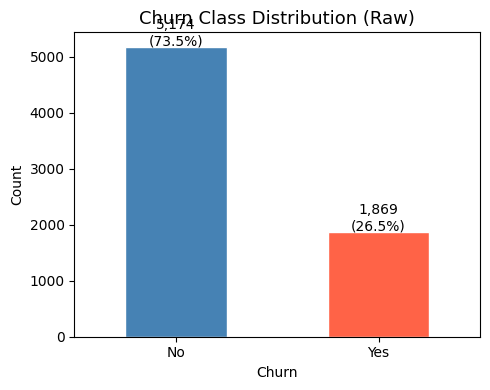

In [8]:
# --- 2.5 Class imbalance ---
churn_counts = df_raw['Churn'].value_counts()
churn_pct = df_raw['Churn'].value_counts(normalize=True) * 100

print('=== Churn Distribution ===')
print(pd.DataFrame({'Count': churn_counts, 'Percentage': churn_pct.round(2)}))

fig, ax = plt.subplots(figsize=(5, 4))
churn_counts.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='white', ax=ax)
ax.set_title('Churn Class Distribution (Raw)')
ax.set_xlabel('Churn')
ax.set_ylabel('Count')
ax.set_xticklabels(['No', 'Yes'], rotation=0)
for i, v in enumerate(churn_counts):
    ax.text(i, v + 30, f'{v:,}\n({churn_pct.iloc[i]:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [9]:
# --- 2.6 TotalCharges vs derived estimate ---
df_check = df_raw.copy()
df_check['TC_numeric'] = pd.to_numeric(df_check['TotalCharges'], errors='coerce')
df_check['TC_derived'] = df_check['tenure'] * df_check['MonthlyCharges']
df_check['TC_gap'] = (df_check['TC_numeric'] - df_check['TC_derived']).abs()

print('Gap between TotalCharges and tenure × MonthlyCharges:')
print(df_check['TC_gap'].describe().round(2))

Gap between TotalCharges and tenure × MonthlyCharges:
count   7032.00
mean      45.09
std       49.90
min        0.00
25%        9.44
50%       28.65
75%       63.70
max      373.25
Name: TC_gap, dtype: float64


## 3. Preprocessing Pipeline

In [10]:
df = df_raw.copy()

# --- Step 1: Drop non-informative identifier ---
df.drop(columns=['customerID'], inplace=True)
print('Step 1 done: customerID dropped.')

Step 1 done: customerID dropped.


In [11]:
# --- Step 2: Fix TotalCharges (blank → 0.0, then cast to float) ---
# Decision: tenure=0 means no billing has occurred yet → TotalCharges = 0.0
df['TotalCharges'] = df['TotalCharges'].str.strip()          # strip whitespace
df['TotalCharges'] = df['TotalCharges'].replace('', '0.0')   # blank → '0.0'
df['TotalCharges'] = df['TotalCharges'].astype(float)         # cast to float

print('Step 2 done: TotalCharges fixed.')
print(f'  NaNs remaining: {df["TotalCharges"].isnull().sum()}')
print(f'  Zero values (new customers): {(df["TotalCharges"] == 0.0).sum()}')

Step 2 done: TotalCharges fixed.
  NaNs remaining: 0
  Zero values (new customers): 11


In [12]:
# --- Step 3: Harmonize SeniorCitizen encoding ---
# Decision: convert 0/1 integer to 'No'/'Yes' string, matching all other binary columns
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print('Step 3 done: SeniorCitizen re-encoded.')
print(df['SeniorCitizen'].value_counts())

Step 3 done: SeniorCitizen re-encoded.
SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64


In [13]:
# --- Step 4: Collapse third-state values in gated columns ---
# Decision: 'No phone service' and 'No internet service' → 'No'
# The parent column (PhoneService / InternetService) already captures this info.

df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

inet_addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                   'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in inet_addon_cols:
    df[col] = df[col].replace('No internet service', 'No')

print('Step 4 done: third-state values collapsed to No.')
print('MultipleLines:', df['MultipleLines'].unique())
print('OnlineSecurity:', df['OnlineSecurity'].unique())

Step 4 done: third-state values collapsed to No.
MultipleLines: ['No' 'Yes']
OnlineSecurity: ['No' 'Yes']


In [14]:
# --- Step 5: Encode target variable Churn as binary integer ---
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print('Step 5 done: Churn encoded.')
print(df['Churn'].value_counts())

Step 5 done: Churn encoded.
Churn
0    5174
1    1869
Name: count, dtype: int64


In [15]:
# --- Step 6: Standardize column names to snake_case ---
df.columns = (
    df.columns
    .str.strip()
    .str.replace(r'([a-z])([A-Z])', r'\1_\2', regex=True)
    .str.lower()
)

print('Step 6 done: columns renamed.')
print(df.columns.tolist())

Step 6 done: columns renamed.
['gender', 'senior_citizen', 'partner', 'dependents', 'tenure', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'churn']


In [16]:
# --- Final check: any remaining NaNs? ---
print('Remaining NaN counts:')
print(df.isnull().sum())
print(f'\nFinal shape: {df.shape}')

Remaining NaN counts:
gender               0
senior_citizen       0
partner              0
dependents           0
tenure               0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn                0
dtype: int64

Final shape: (7043, 20)


## 4. Summary Statistics — Cleaned Data

In [17]:
# --- 4.1 Numeric column summary ---
print('=== Numeric Columns ===')
df.describe().T

=== Numeric Columns ===


,count,mean,std,min,25%,50%,75%,max
tenure,7043.00,32.37,24.56,0.00,9.00,29.00,55.00,72.00
monthly_charges,7043.00,64.76,30.09,18.25,35.50,70.35,89.85,118.75
total_charges,7043.00,2279.73,2266.79,0.00,398.55,1394.55,3786.60,8684.80
churn,7043.00,0.27,0.44,0.00,0.00,0.00,1.00,1.00


In [18]:
# --- 4.2 Categorical column summary ---
print('=== Categorical Columns ===')
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f'\n{col}:')
    print(df[col].value_counts().to_string())

=== Categorical Columns ===

gender:
gender
Male      3555
Female    3488

senior_citizen:
senior_citizen
No     5901
Yes    1142

partner:
partner
No     3641
Yes    3402

dependents:
dependents
No     4933
Yes    2110

phone_service:
phone_service
Yes    6361
No      682

multiple_lines:
multiple_lines
No     4072
Yes    2971

internet_service:
internet_service
Fiber optic    3096
DSL            2421
No             1526

online_security:
online_security
No     5024
Yes    2019

online_backup:
online_backup
No     4614
Yes    2429

device_protection:
device_protection
No     4621
Yes    2422

tech_support:
tech_support
No     4999
Yes    2044

streaming_tv:
streaming_tv
No     4336
Yes    2707

streaming_movies:
streaming_movies
No     4311
Yes    2732

contract:
contract
Month-to-month    3875
Two year          1695
One year          1473

paperless_billing:
paperless_billing
Yes    4171
No     2872

payment_method:
payment_method
Electronic check             2365
Mailed check       

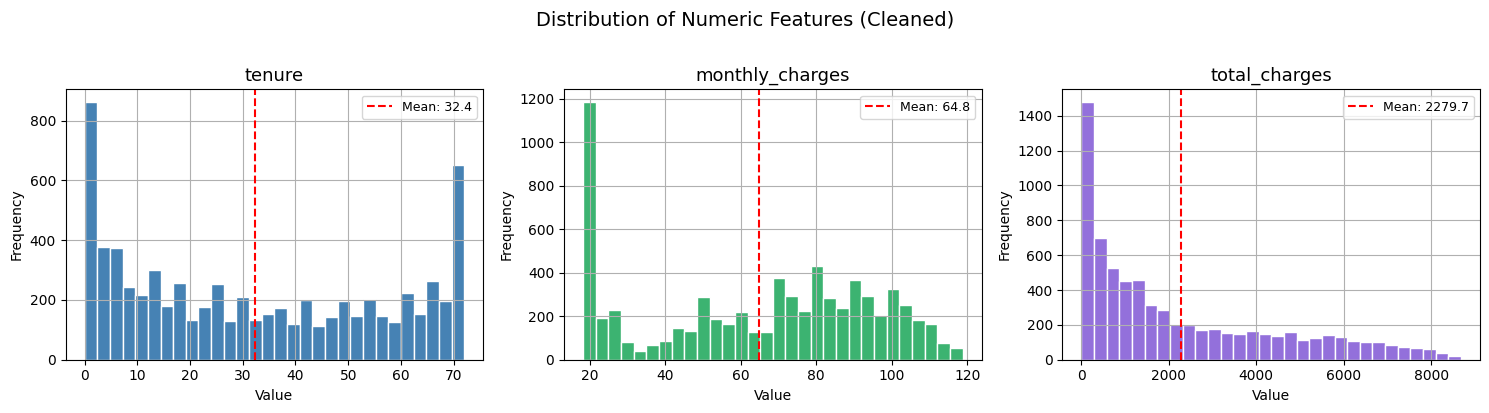

In [19]:
# --- 4.3 Numeric distributions ---
num_cols = ['tenure', 'monthly_charges', 'total_charges']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['steelblue', 'mediumseagreen', 'mediumpurple']

for ax, col, color in zip(axes, num_cols, colors):
    df[col].hist(bins=30, ax=ax, color=color, edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    ax.legend(fontsize=9)

plt.suptitle('Distribution of Numeric Features (Cleaned)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

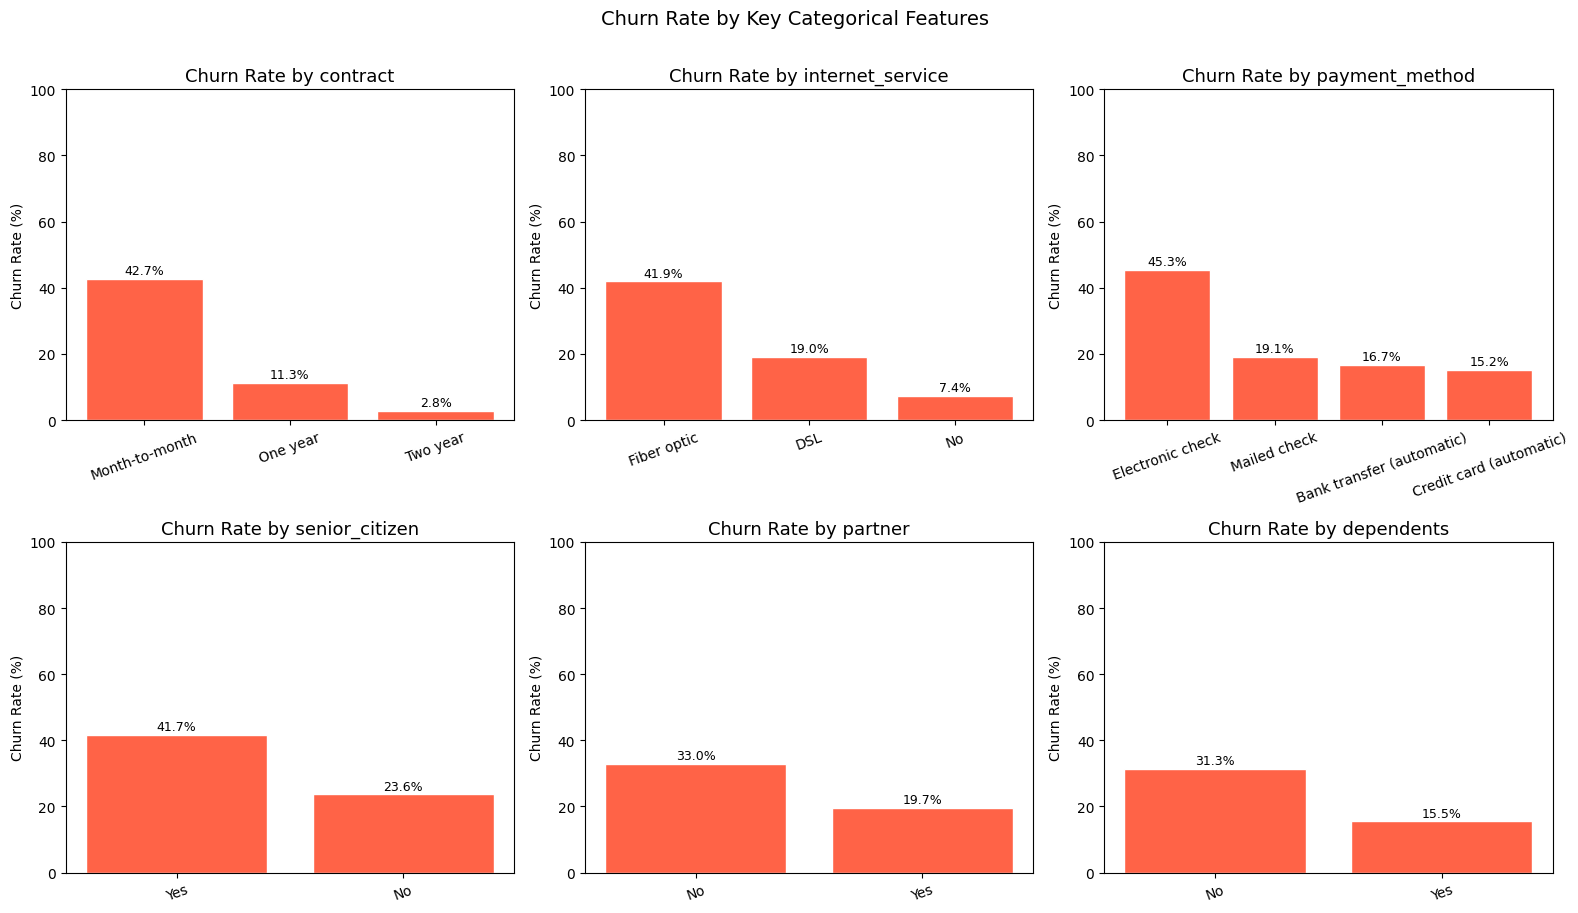

In [20]:
# --- 4.4 Churn rate by key categorical columns ---
key_cats = ['contract', 'internet_service', 'payment_method',
            'senior_citizen', 'partner', 'dependents']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, key_cats):
    churn_rate = df.groupby(col)['churn'].mean().sort_values(ascending=False)
    bars = ax.bar(churn_rate.index, churn_rate.values * 100,
                  color='tomato', edgecolor='white')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1.5,
                f'{val*100:.1f}%', ha='center', fontsize=9)

plt.suptitle('Churn Rate by Key Categorical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

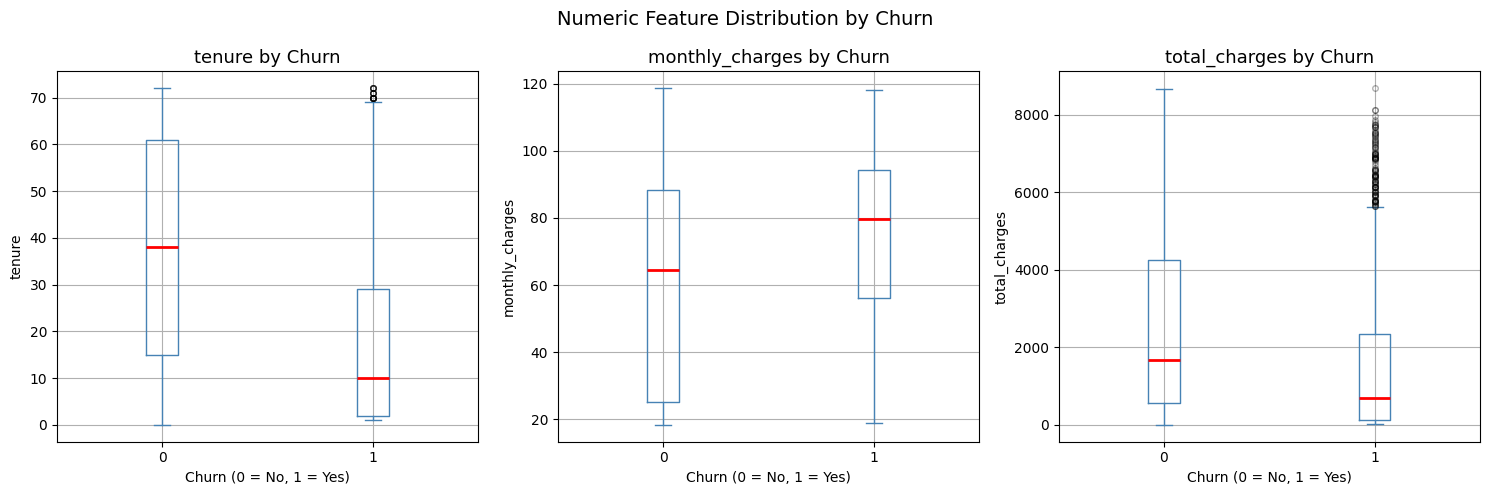

In [21]:
# --- 4.5 Numeric features vs Churn (boxplots) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, by='churn', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='steelblue'),
               capprops=dict(color='steelblue'),
               flierprops=dict(marker='o', color='gray', alpha=0.3, markersize=4))
    ax.set_title(f'{col} by Churn')
    ax.set_xlabel('Churn (0 = No, 1 = Yes)')
    ax.set_ylabel(col)

plt.suptitle('Numeric Feature Distribution by Churn', fontsize=14)
plt.tight_layout()
plt.show()

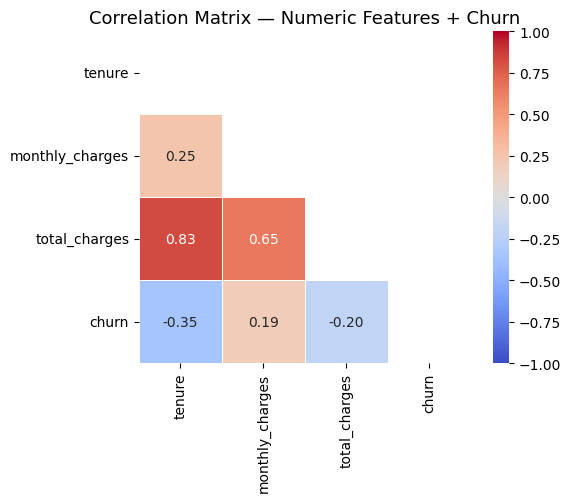

In [22]:
# --- 4.6 Correlation heatmap (numeric + encoded target) ---
corr_df = df[num_cols + ['churn']].copy()
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Correlation Matrix — Numeric Features + Churn')
plt.tight_layout()
plt.show()

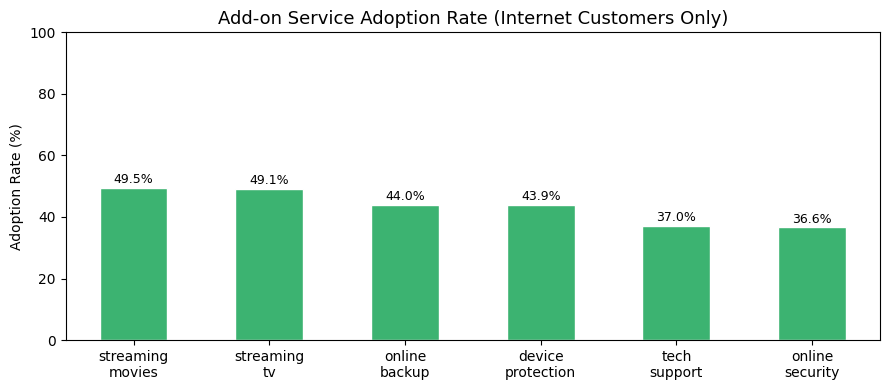

In [23]:
# --- 4.7 Add-on service adoption rates (cleaned, internet customers only) ---
inet_customers = df[df['internet_service'] != 'No'].copy()
addon_cols = ['online_security', 'online_backup', 'device_protection',
              'tech_support', 'streaming_tv', 'streaming_movies']

adoption = {col: (inet_customers[col] == 'Yes').mean() * 100 for col in addon_cols}
adoption_s = pd.Series(adoption).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
adoption_s.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title('Add-on Service Adoption Rate (Internet Customers Only)')
ax.set_ylabel('Adoption Rate (%)')
ax.set_ylim(0, 100)
ax.set_xticklabels([c.replace('_', '\n') for c in adoption_s.index], rotation=0)
for i, v in enumerate(adoption_s.values):
    ax.text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

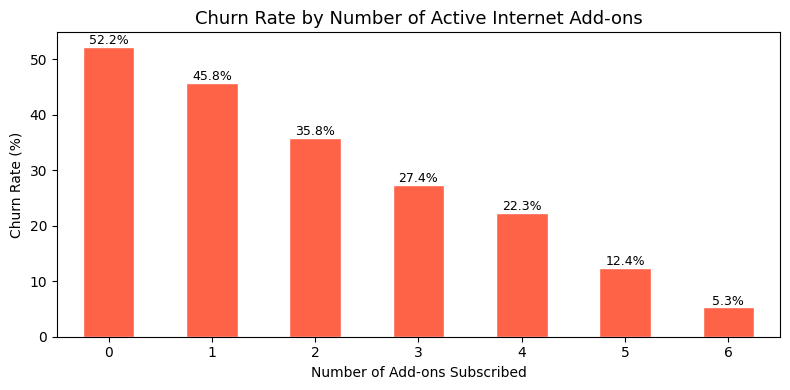

In [24]:
# --- 4.8 Churn rate by number of active add-ons ---
inet_customers = df[df['internet_service'] != 'No'].copy()
for col in addon_cols:
    inet_customers[col + '_bin'] = (inet_customers[col] == 'Yes').astype(int)

inet_customers['num_addons'] = inet_customers[[c + '_bin' for c in addon_cols]].sum(axis=1)
addon_churn = inet_customers.groupby('num_addons')['churn'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
addon_churn.plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
ax.set_title('Churn Rate by Number of Active Internet Add-ons')
ax.set_xlabel('Number of Add-ons Subscribed')
ax.set_ylabel('Churn Rate (%)')
ax.set_xticklabels(addon_churn.index, rotation=0)
for i, v in enumerate(addon_churn.values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Export Cleaned Dataset

In [25]:
output_path = 'telco_churn_cleaned.csv'
df.to_csv(output_path, index=False)
print(f'Cleaned dataset saved to: {output_path}')
print(f'Final shape: {df.shape}')
print('\nColumn dtypes:')
print(df.dtypes)

Cleaned dataset saved to: telco_churn_cleaned.csv
Final shape: (7043, 20)

Column dtypes:
gender                object
senior_citizen        object
partner               object
dependents            object
tenure                 int64
phone_service         object
multiple_lines        object
internet_service      object
online_security       object
online_backup         object
device_protection     object
tech_support          object
streaming_tv          object
streaming_movies      object
contract              object
paperless_billing     object
payment_method        object
monthly_charges      float64
total_charges        float64
churn                  int64
dtype: object


## 6. Preprocessing Summary

| Step | Action | Rows Affected |
|------|--------|---------------|
| Drop `customerID` | Removed identifier column | All |
| Fix `TotalCharges` | Cast to float; blank → `0.0` | 11 |
| Harmonize `SeniorCitizen` | `0/1` → `'No'/'Yes'` | All |
| Collapse gated columns | `'No phone/internet service'` → `'No'` in 7 columns | ~1,526 (no internet) + ~682 (no phone) |
| Encode `Churn` | `'Yes'/'No'` → `1/0` | All |
| Rename columns | camelCase → snake_case | All |

**Records retained:** 7,043 / 7,043 (no rows dropped)  
**Churn imbalance ratio:** ~2.77:1 (No:Yes) — handle with class weights or resampling at modeling stage.